[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py_ua/syn_ua_03_order_parameters_slaving.ipynb)


# 03. Параметри порядку і принцип підпорядкування

_Магістерський курс «Вступ до синергетики» · українська версія_

> **Провідне питання:** Коли швидкі змінні можна виразити через кілька повільних нестійких мод?

**Як працювати з ноутбуком.** Виконуйте комірки послідовно, згори донизу. Якщо не зазначено інше, усі параметри безрозмірні. Пояснюйте зміст кожної діагностики: сама лише ефектна траєкторія ще не доводить самоорганізації.


## Результати навчання

Після опрацювання модуля ви зможете:

- розрізняти м'які та стійкі моди за швидкостями їх релаксації;
- вивести співвідношення підпорядкування в головному наближенні;
- кількісно оцінити похибку та межі застосовності адіабатичного виключення.


## Необхідний вступ: розділення часових масштабів

Нехай $A$ змінюється за час $T_s$, а $B$ — за значно коротший час $T_f$. Після масштабування часом $T_s$ у швидкому рівнянні з'являється малий параметр $\varepsilon=T_f/T_s\ll1$. Протягом початкового шару тривалістю $O(\varepsilon)$ змінна $B$ швидко наближається до повільного многовиду. Після цього її часто можна наближено подати як $B=h(A)$.

Прирівнювання швидкої похідної до нуля — це головне наближення, а не тотожність. Його слід перевіряти, змінюючи $\varepsilon$, відкидаючи початковий шар і контролюючи стійкість швидкої рівноваги вздовж траєкторії. Поблизу другої нестійкості, резонансу або втрати нормальної гіперболічності підпорядкування може порушитися.


## Прототип системи з повільною і швидкою змінними

Розглянемо

$$\dot A=\mu A-A^3+cAB,\qquad \varepsilon\dot B=-B+dA^2.$$

Поблизу $\mu=0$ змінна $A$ є повільною, тоді як $B$ релаксує зі швидкістю $1/\varepsilon$ ($\varepsilon\ll 1$). Якщо в головному наближенні прирівняти швидку похідну до нуля, одержимо співвідношення $B\approx dA^2$ та редуковане рівняння амплітуди

$$\dot A=\mu A-(1-cd)A^3.$$

Це не механічне вилучення змінної, а наближення, похибка якого залежить від розділення масштабів, відстані до нестійкості, початкового шару та нормальної гіперболічності швидкого многовиду.


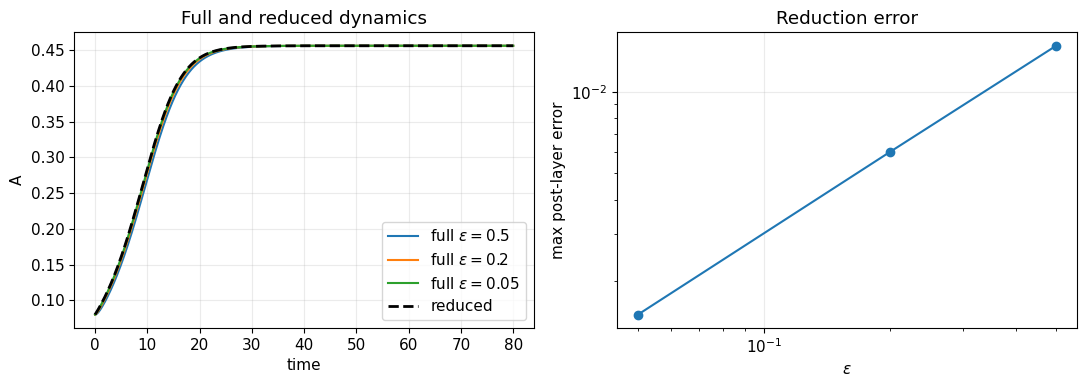

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

from scipy.integrate import solve_ivp

mu, c, d = 0.15, 0.35, 0.8
t_eval = np.linspace(0, 80, 3000)

def full_system(t, y, eps):
    A, B = y
    return mu*A - A**3 + c*A*B, (-B + d*A**2)/eps

def reduced_system(t, y):
    A = y[0]
    return [mu*A - (1-c*d)*A**3]

reduced = solve_ivp(reduced_system, (0, 80), [0.08], t_eval=t_eval, rtol=1e-9, atol=1e-11)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
errors = []
for eps in [0.5, 0.2, 0.05]:
    full = solve_ivp(full_system, (0, 80), [0.08, -0.4], args=(eps,), t_eval=t_eval,
                     rtol=1e-9, atol=1e-11)
    ax[0].plot(t_eval, full.y[0], label=fr"full $\epsilon={eps}$")
    mask = t_eval > 5*eps
    errors.append(np.max(np.abs(full.y[0, mask] - reduced.y[0, mask])))
ax[0].plot(t_eval, reduced.y[0], "k--", lw=2, label="reduced")
ax[0].set(xlabel="time", ylabel="A", title="Full and reduced dynamics")
ax[0].legend()
ax[1].loglog([0.5, 0.2, 0.05], errors, "o-")
ax[1].set(xlabel=r"$\epsilon$", ylabel="max post-layer error", title="Reduction error")
plt.tight_layout()


## Погляд з теорії центральних многовидів

Графік $B=h(A,\mu)$ має задовольняти рівняння інваріантності, а не лише умову $\dot B=0$. Розклад $h=dA^2+O(\varepsilon,A^4,\mu A^2)$ дає систематичні поправки. Отже, принцип підпорядкування є фізичною інтерпретацією локальної редукції на інваріантний многовид поблизу втрати стійкості.

> **Контрольна думка:** Самої швидкої релаксації недостатньо, якщо швидка підсистема втрачає стійкість, зовнішня дія резонує з нею або траєкторія виходить з околу, де справедливий розклад.


## Оцінюване завдання

Виведіть першу поправку порядку $O(\varepsilon)$ до $B=h(A)$ з рівняння інваріантності. Додайте її до редукованої моделі, повторіть побудову похибки та визначте спостережуваний порядок збіжності за $\varepsilon$.

Подання має містити чітке твердження, його математичне або фізичне обґрунтування, числові свідчення та принаймні одне обмеження висновку.


## Література та атрибуція

**Основне читання з локальної бібліотеки:** Haken, *Synergetics: An Introduction* та *Synergetics: Introduction and Advanced Topics*, розділи про параметри порядку і принцип підпорядкування.

**Перевірене вебджерело:**
- [Haken, Synergetics: An Introduction](https://doi.org/10.1007/978-3-642-88338-5)

Локальні книги є наданими матеріалами курсу. Вебпосилання мають додатковий характер; їх перевірено 04.09.2026.
